# SIDNE 1 Model 2035-2050 
(Spain Industry Decarbonisation with Nuclear Energy) 

This first module focuses in the Chemical Industry decarbonization with SMR-CHP 
(Economic analysis using PyPSA opensource toolbox)

Hypothesis: 
- Demand data from MECs (3% scaled down to spain case;  check calculus [file](https://docs.google.com/spreadsheets/d/1pLw4c-ZX__JsrjUIHaK1mmeCst81JXG1elViPpqSP6U/edit?gid=889823888#gid=889823888))
- Interest Rate Nominal conservative = 8% ([NREL](https://atb.nrel.gov/electricity/2024/data) ATB data)
- SMR costs from [NREL](https://atb.nrel.gov/electricity/2024/data). 
- GAS-CHP costs from PyPSA or [NREL](https://atb.nrel.gov/electricity/2024/data). 


The code is based in: 
- [basic example](https://pypsa.readthedocs.io/en/latest/examples/chp-fixed-heat-power-ratio.html), [Biomass example](https://pypsa.readthedocs.io/en/latest/examples/biomass-synthetic-fuels-carbon-management.html), and [variable heat-power example](https://pypsa.readthedocs.io/en/latest/examples/power-to-gas-boiler-chp.html)
- Previous work developed by Antonio Vaya and Daniel Juiz

In [1]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
import pandas as pd
import pypsa
import packages
# conda install openpyxl
# plt.style.use("bmh")


## 1. Units_from_Costs_final2024.xml input (2023)
  - Investment (Overnight capital cost): USD/kWe*--> (Will be annualized to be used in SIDNE PyPSA Model)
  - FOM: USD/kW/year
  - VOM: USD/MWh
  - Fuel: USD/MWh
  - Lifetime: years
  - carbon_intensity: gCO2/kWh
  - Capacity: MW (Net Capacity Factor: NREL)
  - Constrution time: years
  - load_factor: Unitarized
  - Tax: Unitarized
  - Rate: Unitarized 
  - Carbon_cost: USD/ton CO2 (in is not used in PyPSA)

In [2]:
#This line comented can be used to updated the costs from a cost_final24.xlsx Excel file

# cost=pd.read_excel('./cost_final24.xlsx') #read from an excel file which is converted to csv
# csv_file11 = "./cost_final24.csv" # Specify the output CSV file path
# cost.to_csv(csv_file11, index=False) #Save the DataFrame as a CSV file

#Costs updated, cost.final24.csv in directory, saved in the cost Data Frame
cost=pd.read_csv('./cost_final24.csv', index_col=0)

#Sensibility parameters
select_rate=cost.loc["SMR_CHP","rate"] 

### Configure costs and Calculate LCOE for each tech

In [3]:
# Compute all LCOEs
df = pd.DataFrame()
techs=['SMR_CHP', 'Gas_CHP']

for tech in techs:
    df=pd.concat([df, packages.LCOE(tech, cost, tech)])
# df

Add: 
- Carbon costs, from the 2024 World Energy Outlook [website](https://www.iea.org/reports/world-energy-outlook-2024). 
- Carbon intensity values to compute CO2 emissions
- Taxes to nuclear energy: taken from PWC'[report](https://www.pwc.es/es/publicaciones/energia/assets/fiscalidad-parque-nuclear.pdf).

In [4]:
#Carbon costs updated to 90 USD/tonCO2 by 2024 World Energy Outlook.
cost.loc["Gas_CHP", "carbon_cost"]=90.  # USD/tonCO2
cost["tax"] = cost["tax"].astype(float)

#Adding carbon intensity in tCO2/MWh_th (from gCO2/kWh)
cost["carbon_intensity"] = cost["carbon_intensity"].astype(float)
cost.loc["Gas_CHP", "carbon_intensity"]=cost.loc["Gas_CHP", "carbon_intensity"]*0.5/1000
# cost

#impact of taxes, 16.31 // Source PWC 
cost.loc["SMR_CHP", "tax"]=16.31

Annualize investment values

In [5]:
#annualiaze investment costs
lifetime= cost["lifetime"].values

annualized_inv=[packages.annualized(val, select_rate, lifetime[i])*1000 for i, val 
in enumerate(cost["investment"].values)] #1000_factor_to_convert_to_USD/MW/year

cost["annualized_investment"]=annualized_inv #Add to cost dataframe

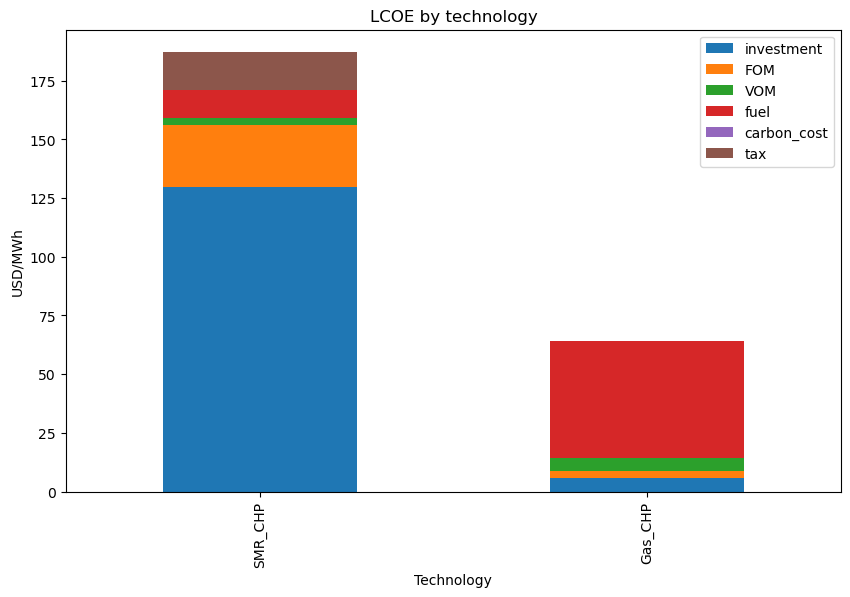

In [6]:
#Plot LCOE
df3 = pd.DataFrame()
for tech in techs:
    df3=pd.concat([df3, packages.LCOE(tech, cost, tech)])

df3['Total'] = df3.sum(axis=1)
df3 = df3.sort_values(by='Total', ascending=False)
df3 = df3.drop(columns=['Total'])

df3.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Technology')
plt.ylabel('USD/MWh')
plt.title('LCOE by technology')
plt.show()

### Units of cost_dataframe for PyPSA model

  - Investment (Overnight capital cost): USD/kWe
  - FOM: USD/kW/year
  - VOM: USD/MWh
  - Fuel: USD/MWh
  - Lifetime: years
  - carbon_intensity: gCO2/kWh
  - Capacity: MW (Net Capacity Factor: NREL)
  - Constrution time: years
  - load_factor: Unitarized
  - Tax: Unitarized
  - Rate: Unitarized
  - Carbon_cost: USD/ton CO2
  - annualized_investment: USD/MWe/year

## 2. SMR vs Gas CHP + electric grid

First upload 2023 historical data: profiles, loads and prices
(Source:  [ENTSOE Transparency Platform](https://newtransparency.entsoe.eu/generation/installed/perType?appState=%7B%22sa%22%3A%5B%22BZN%7C10YES-REE------0%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22TABLE%22%2C%22df%22%3A%5B%222024%22%2C%222024%22%5D%2C%22tz%22%3A%22CET%22%7D))

![Alt text](ElectricityPrices23.png)

In [7]:
CO2_reduction=0.5 # 50% CO2 emissions reduction for scenario 2035
# Using a carbon cost of: 90 USD/tonCO2 by 2024 World Energy Outlook --> cost.loc["Gas_CHP", "carbon_cost"]=90.
extra_cost=10000

# Filtrar un rango de tiempo específico (para comprobar hipótesis)------
start_time = "2023-01-02 02:00:00"                                         
end_time = "2023-01-02 9:00:00"                                        
# end_time = "2023-12-31 23:00:00"              # All 8760 hours of simulation 
snapshots=pd.date_range(start_time, end_time, freq="h")
#----------------------------------------------------------------------------------------
#----------------------------------------------------------------------------------------
    # Cargar el archivo ES_Price.csv e indexarlo con una serie temporal
price_data = pd.read_csv('./ES_Price.csv')
price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
filtered_prices = price_data.loc[start_time:end_time]
# print(filtered_prices) # Verifica que los datos filtrados sean correctos
PriceES = pd.read_csv('./ES_Price.csv').iloc[:len(snapshots)]
assert len(PriceES) == len(snapshots), "El número de filas en PriceES no coincide con los snapshots"

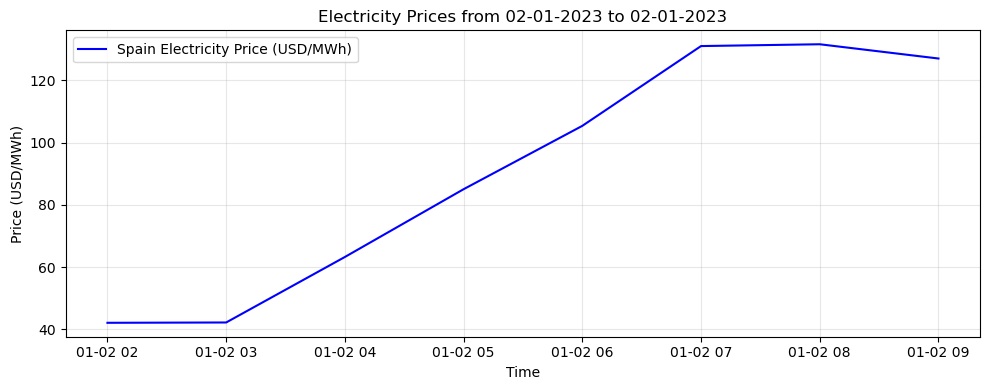

In [8]:
# Graficar los precios en el rango de tiempo
plt.figure(figsize=(10, 4))
plt.plot(snapshots, filtered_prices["Price"], label="Spain Electricity Price (USD/MWh)", color="blue")
plt.xlabel("Time")
plt.ylabel("Price (USD/MWh)")
# Ajustar el título para mostrar solo día, mes y año
start_date = pd.to_datetime(start_time).strftime("%d-%m-%Y")
end_date = pd.to_datetime(end_time).strftime("%d-%m-%Y")
plt.title(f"Electricity Prices from {start_date} to {end_date}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

   Technology  marginal_cost   capital_cost
0     Gas_CHP         55.500   75256.906429
1     SMR_CHP         14.800  983580.513255
2  Spain_grid         90.925   50000.000000


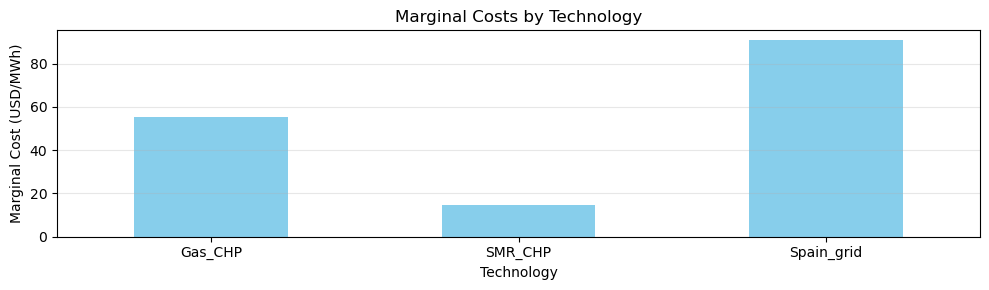

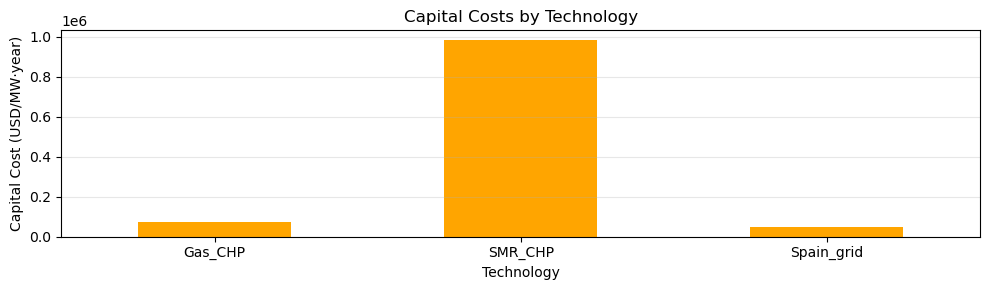

In [9]:
# Calcular los costos marginales y de capital para cada tecnología
Gas_marginal_cost = cost.loc["Gas_CHP", "VOM"] + cost.loc["Gas_CHP", "fuel"]  # USD/MWh
Gas_capital_cost = cost.loc["Gas_CHP", "annualized_investment"] + cost.loc["Gas_CHP", "FOM"] * 1000  # USD/MW·year

SMR_marginal_cost = cost.loc["SMR_CHP", "VOM"] + cost.loc["SMR_CHP", "fuel"]  # USD/MWh
SMR_capital_cost = cost.loc["SMR_CHP", "annualized_investment"] + cost.loc["SMR_CHP", "FOM"] * 1000  # USD/MW·year

Spain_grid_marginal_cost = filtered_prices["Price"].mean()  # Promedio de precios eléctricos (USD/MWh)
Spain_grid_capital_cost = 50000  # USD/MW·year (según el ejemplo)

# Crear el DataFrame
costs_df = pd.DataFrame({
    "Technology": ["Gas_CHP", "SMR_CHP", "Spain_grid"],
    "marginal_cost": [Gas_marginal_cost, SMR_marginal_cost, Spain_grid_marginal_cost],
    "capital_cost": [Gas_capital_cost, SMR_capital_cost, Spain_grid_capital_cost]
})

# Mostrar el DataFrame
print(costs_df)

# Graficar los costos marginales
plt.figure(figsize=(10, 3))
costs_df.set_index("Technology")["marginal_cost"].plot(
    kind="bar", color="skyblue", legend=False
)
plt.title("Marginal Costs by Technology")
plt.ylabel("Marginal Cost (USD/MWh)")
plt.xlabel("Technology")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Graficar los costos de capital
plt.figure(figsize=(10, 3))
costs_df.set_index("Technology")["capital_cost"].plot(
    kind="bar", color="orange", legend=False
)
plt.title("Capital Costs by Technology")
plt.ylabel("Capital Cost (USD/MW·year)")
plt.xlabel("Technology")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
network=pypsa.Network() # Creates empty PyPSA network object called network
#Each hour is going to be a snapshot to optimize (Historical data loaded, as ES prices, have 8760 inputs)
network.set_snapshots(snapshots) # set the time range with hourly frequency

# 0) define carriers (optional) and co2 constraint
network.add("Carrier", "Gas",
            co2_emissions=cost.loc["CCGT","carbon_intensity"]) 
network.add("Carrier", "nuclear")
network.add("Carrier", "heat")
network.add("Carrier","electricity")

# 0.1) Define emissions constraint
# CO2_avoided=cost.loc["Gas_CHP", "carbon_intensity"]*2.92E+06 # 2.92E+06 fuel avoided in MWh/year (maximum avoided [MECS 2018] considering fuel as 100% natural gas) 
# limit_CO2=CO2_avoided*CO2_reduction # 50% reduction of CO2 emissions in tCO2/year
# network.add("GlobalConstraint", "co2_limit", sense="<=", constant=limit_CO2)

# 1) Main Buses & loads----------------------------------------------------------------
network.add("Bus", "Industry Electricity", carrier="electricity") 
network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=135)

network.add("Bus", "Industry Heat", carrier="heat")
network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=294) # 294

# 2)  Fuel buses ----------------------------------------------------------------------
network.add("Bus", "uranium_UO2", carrier="nuclear")                  
network.add("Bus", "Gas_Fuel_in", carrier="Gas")
network.add("Bus", "Spain_grid", carrier="electricity")

# STORES ------------------------------------------------------------------------------
network.add("Store", "Spain gas", bus="Gas_Fuel_in",
    e_initial=100, 
    # e_nom=0,    # set pre-existing e_nom=50?
    e_cyclic=True,
    e_nom_extendable=True)
network.add("Store", "uranium", bus="uranium_UO2",
    e_initial=100, 
    # e_nom=0, # set pre-existing e_nom=0?
    e_cyclic=True,
    e_nom_extendable=True)
network.add("Store", "Spain grid", bus="Spain_grid",
    e_initial=100, 
    # e_nom=100, # set pre-existing e_nom=0?
    e_cyclic=True,
    e_nom_extendable=True)

# Dump components as inverted generators------------------------------------------------
network.add("Generator","Electricity_Market",
    bus="Industry Electricity",
    p_nom=0,
    p_nom_max=400,
    p_nom_extendable=True,
    marginal_cost= (10+extra_cost), # selling prices as income (USD/MWh)
    carrier="electricity", 
    efficiency=-1) # consumes energy from bus, instead of generating it

network.add("Generator","Heat_Dump",
    bus="Industry Heat",
    p_nom=0,
    p_nom_max=400,
    p_nom_extendable=True,
    marginal_cost= (extra_cost+400000), # low cost for dumping
    carrier="heat", 
    efficiency=-1) # consumes energy from bus, instead of generating it

# LINKS----------------------------------------------------------------------------------
network.add( "Link", "Link_Gas_CHP",               
    bus0="Gas_Fuel_in",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    carrier="Gas",
    p_nom=400,            # fixed p_nom Gas installed
    p_nom_extendable=True, # Optimizes de p_nom value
    capital_cost=cost.loc["Gas_CHP","annualized_investment"]+cost.loc["Gas_CHP","FOM"]*1000,     # fixed period costs of extending p_nom by 1 MW
    marginal_cost=(cost.loc["Gas_CHP","VOM"]+cost.loc["Gas_CHP","fuel"]), 
    efficiency=0.4, 
    efficiency2=0.35,
)
network.add( "Link", "Link_SMR_CHP",
    bus0="uranium_UO2",
    bus1="Industry Electricity",
    bus2="Industry Heat", 
    carrier="nuclear",
    p_nom=400, # set p_nom=0 initial value?
    p_nom_extendable=True, # Optimizes de p_nom value
    capital_cost=cost.loc["SMR_CHP","annualized_investment"]+cost.loc["SMR_CHP","FOM"]*1000, #annualized USD/MWe
    marginal_cost=(cost.loc["SMR_CHP","VOM"]+cost.loc["SMR_CHP","fuel"]),
    efficiency=0.45, 
    efficiency2=0.35,
)
network.add("Link", "Link_Spain_Grid",
    bus0="Spain_grid",
    bus1="Industry Electricity",
    carrier="electricity",
    p_nom=400, # connection capacity of 500 MW
    # p_nom_min=100,  # Optional: Minimum capacity
    p_nom_extendable=True, 
    capital_cost=Spain_grid_capital_cost,   # no fixed $/MW per period?
    marginal_cost=filtered_prices["Price"].values, # Spain energy prices for 2023
    efficiency=1      # electricity transport
    )
#add electricity to heat link & short-time heat store
network.add(
    "Link",
    "Heat_pump",
    bus0="Industry Electricity",
    bus1="Industry Heat",
    efficiency=0.9,
    capital_cost=4e7, # USD/MW·year
    p_nom_extendable=True,
)
# network.add("Store", "water tank", bus="Industry Heat", 
#             e_initial=1000,
#             e_cyclic=True, 
#             e_nom_extendable=True)

Index(['Heat_pump'], dtype='object')

In [11]:
network.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.11s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 106 primals, 219 duals
Objective: 5.32e+08
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

## 3. Plot Results

In [12]:
print(network.objective)  # Verifica el valor objetivo
print(network.links_t.p0)  # Flujos de energía en los links
network.loads_t.p

531595832.127
Link                 Link_Gas_CHP  Link_SMR_CHP  Link_Spain_Grid  Heat_pump
snapshot                                                                   
2023-01-02 02:00:00          -0.0          -0.0             -0.0       -0.0
2023-01-02 03:00:00          -0.0          -0.0             -0.0       -0.0
2023-01-02 04:00:00          -0.0          -0.0             -0.0       -0.0
2023-01-02 05:00:00          -0.0          -0.0             -0.0       -0.0
2023-01-02 06:00:00          -0.0          -0.0             -0.0       -0.0
2023-01-02 07:00:00          -0.0          -0.0             -0.0       -0.0
2023-01-02 08:00:00          -0.0          -0.0             -0.0       -0.0
2023-01-02 09:00:00          -0.0          -0.0             -0.0       -0.0


Load,Industry Electricity Load,Industry Heat Load
snapshot,,
2023-01-02 02:00:00,135.0,294.0
2023-01-02 03:00:00,135.0,294.0
2023-01-02 04:00:00,135.0,294.0
2023-01-02 05:00:00,135.0,294.0
2023-01-02 06:00:00,135.0,294.0
2023-01-02 07:00:00,135.0,294.0
2023-01-02 08:00:00,135.0,294.0
2023-01-02 09:00:00,135.0,294.0


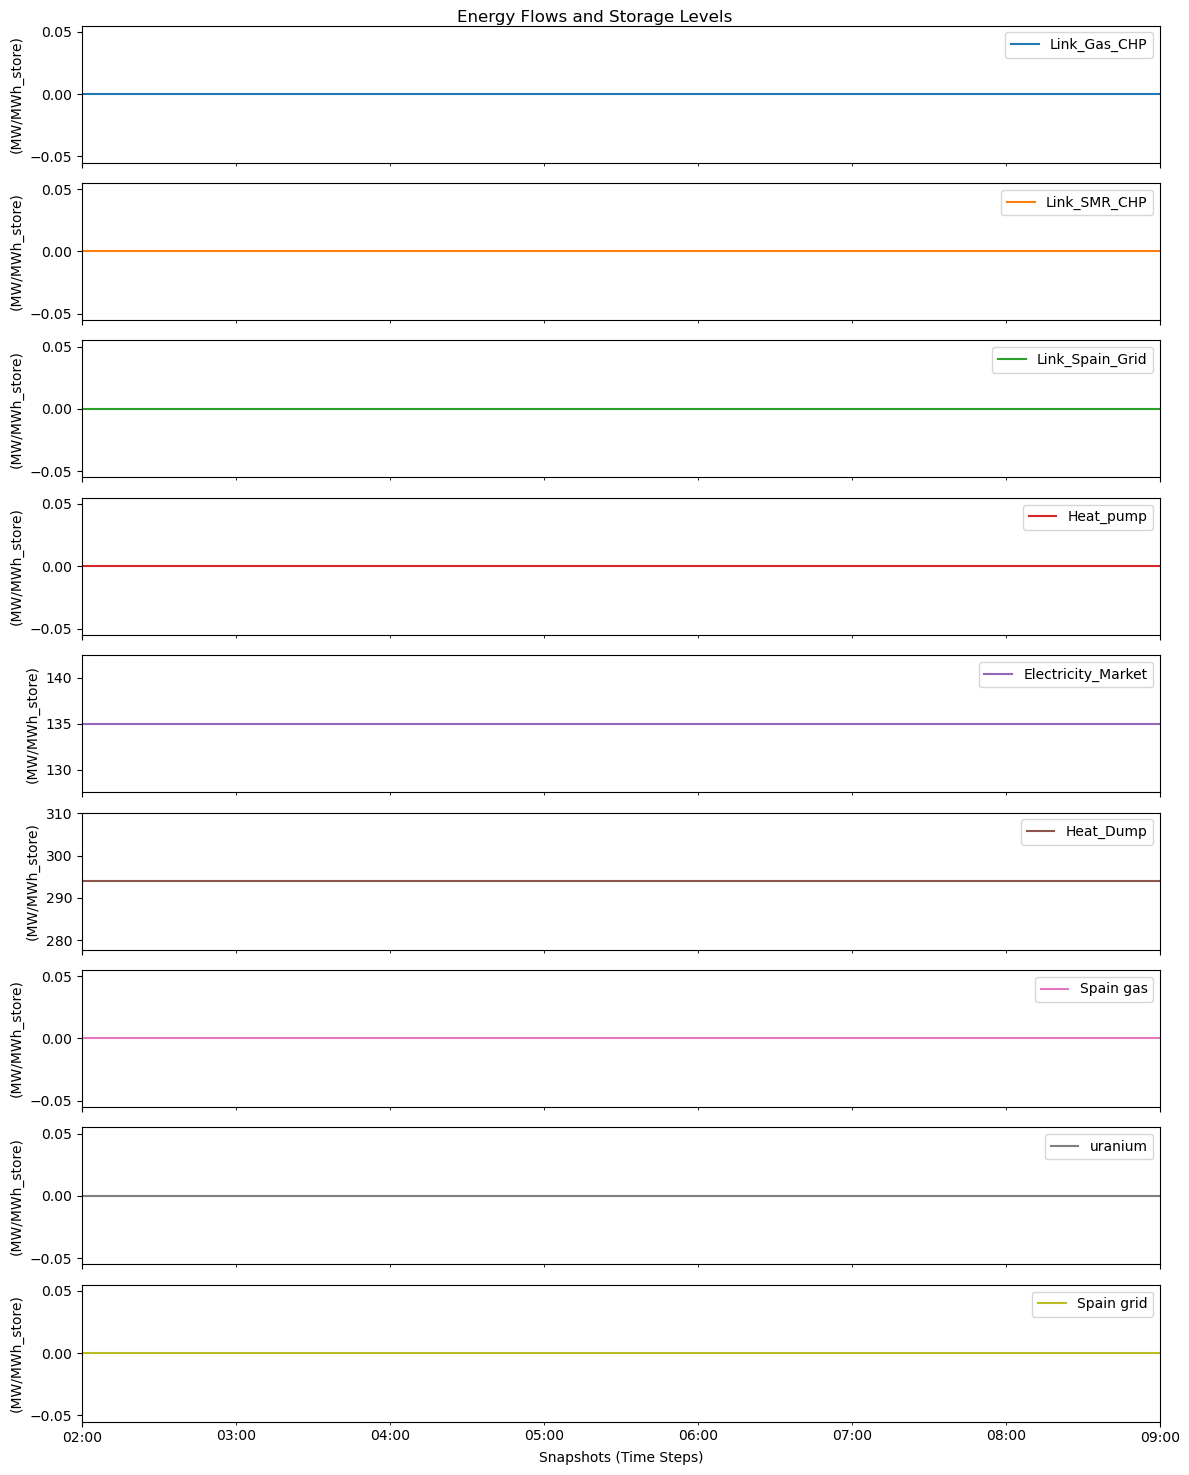

In [13]:
# Combinar datos de links, generadores y almacenes
links_p0 = network.links_t.p0  # Flujos de energía en los links (bus0)
generators_p = network.generators_t.p  # Producción de los generadores
stores_e = network.stores_t.e  # Energía almacenada en los almacenes

# Crear un DataFrame combinado
combined_data = pd.concat([links_p0, generators_p, stores_e], axis=1)

# Graficar los datos combinados en subplots
ax = combined_data.plot(subplots=True, figsize=(12, 15), title="Energy Flows and Storage Levels")

# Configurar etiquetas para cada subplot
for subplot in ax:
    subplot.set_xlabel("Snapshots (Time Steps)")  # Etiqueta del eje x
    subplot.set_ylabel("(MW/MWh_store)")      # Etiqueta del eje y

# Ajustar el diseño para evitar superposición
plt.tight_layout()
plt.show()

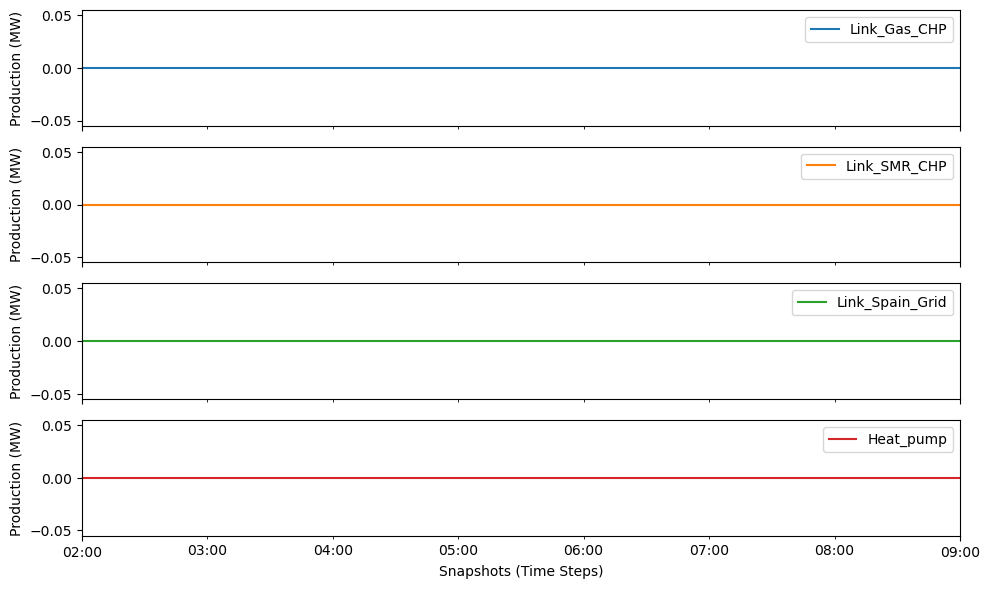

In [14]:
# Plot production view with subplots
ax = network.links_t.p0.plot(subplots=True, figsize=(10, 6))
# Add labels for x and y axes on each subplot
for subplot in ax:
    subplot.set_xlabel("Snapshots (Time Steps)")  # Label for x-axis
    subplot.set_ylabel("Production (MW)")         # Label for y-axis
# Adjust layout to prevent overlapping
plt.tight_layout()

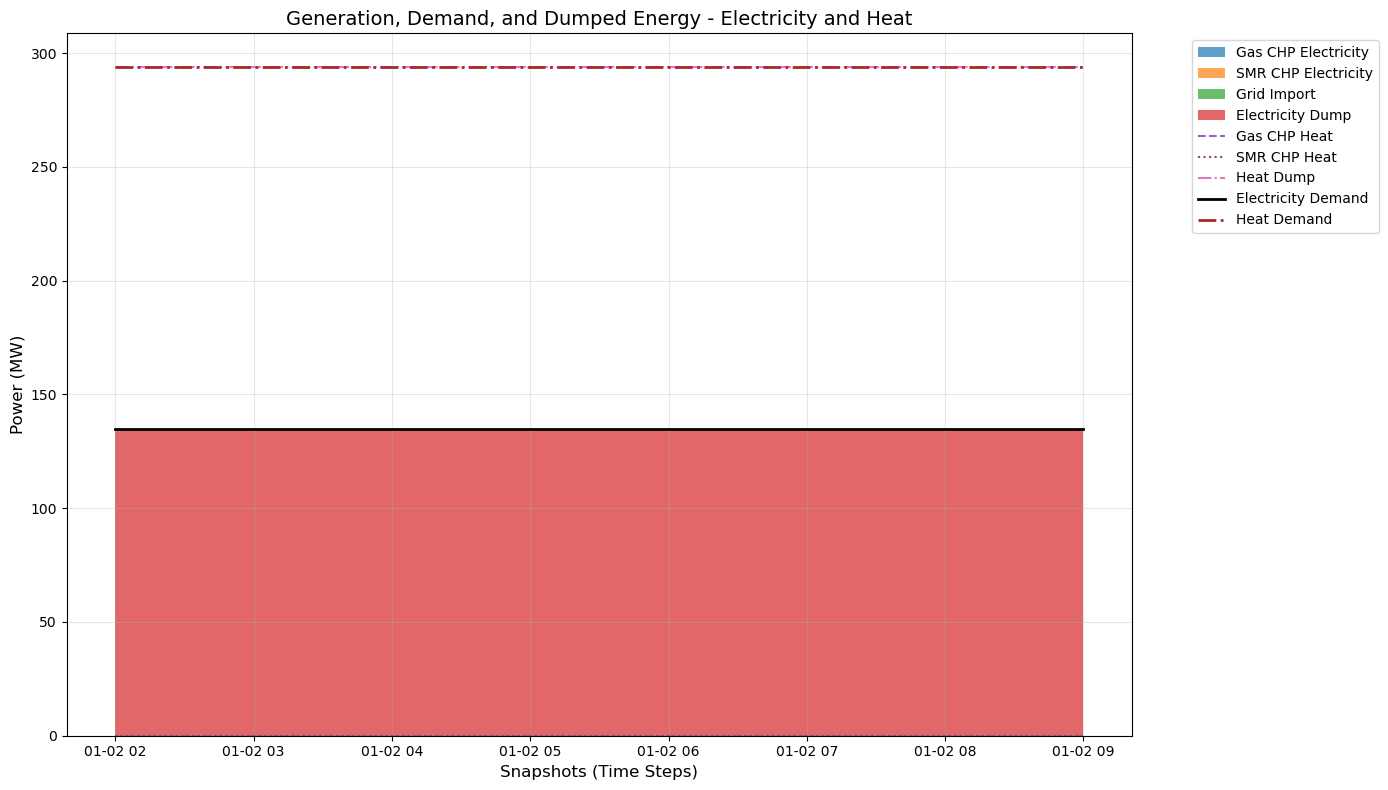

In [15]:
# Extract electricity generation data
generation = pd.concat([
    (-1) * network.links_t.p1["Link_Gas_CHP"],  # Gas_CHP electricity generation
    (-1) * network.links_t.p1["Link_SMR_CHP"],  # SMR_CHP electricity generation
    (-1) * network.links_t.p1["Link_Spain_Grid"],  # Grid electricity import
    network.generators_t.p["Electricity_Market"]  # Electricity dumped into the market
], axis=1)
generation.columns = ["Gas_CHP", "SMR_CHP", "Grid_Import", "Electricity_Dump"]

# Extract heat generation data
heat_generation = pd.concat([
    (-1) * network.links_t.p2["Link_Gas_CHP"],  # Gas_CHP heat generation
    (-1) * network.links_t.p2["Link_SMR_CHP"],  # SMR_CHP heat generation
    network.generators_t.p["Heat_Dump"]  # Heat dumped
], axis=1)
heat_generation.columns = ["Gas_CHP_Heat", "SMR_CHP_Heat", "Heat_Dump"]

# Combine data for plotting
combined = pd.concat([
    generation,
    heat_generation,
    network.loads_t.p["Industry Electricity Load"],  # Electricity demand
    network.loads_t.p["Industry Heat Load"]          # Heat demand
], axis=1)
combined.columns = [
    "Gas_CHP_Elec", "SMR_CHP_Elec", "Grid_Import", "Electricity_Dump",
    "Gas_CHP_Heat", "SMR_CHP_Heat", "Heat_Dump",
    "Elec_Demand", "Heat_Demand"
]
# Plot results
plt.figure(figsize=(14, 8))
# combined = combined.loc[100:200]  # Visualizar 100 horas

# Plot electricity generation as a stacked area chart
plt.stackplot(combined.index,
              combined["Gas_CHP_Elec"],
              combined["SMR_CHP_Elec"],
              combined["Grid_Import"],
              combined["Electricity_Dump"],
              labels=["Gas CHP Electricity", "SMR CHP Electricity", "Grid Import", "Electricity Dump"],
              colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"],
              alpha=0.7)

# Plot heat generation as lines
plt.plot(combined.index, combined["Gas_CHP_Heat"],
         label="Gas CHP Heat", linestyle="--", color="#9467bd")
plt.plot(combined.index, combined["SMR_CHP_Heat"],
         label="SMR CHP Heat", linestyle=":", color="#8c564b")
plt.plot(combined.index, combined["Heat_Dump"],
         label="Heat Dump", linestyle="-.", color="#e377c2")

# Plot demand as lines
plt.plot(combined.index, combined["Elec_Demand"],
         label="Electricity Demand", color="black", linewidth=2)
plt.plot(combined.index, combined["Heat_Demand"],
         label="Heat Demand", color="brown", linewidth=2, linestyle="-.")

# Configure plot
plt.title("Generation, Demand, and Dumped Energy - Electricity and Heat", fontsize=14)
plt.xlabel("Snapshots (Time Steps)", fontsize=12)
plt.ylabel("Power (MW)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
print("SMR Electricity Output:", network.links_t.p1["Link_SMR_CHP"].sum() )  # -MW
print("SMR Heat Output:", network.links_t.p2["Link_SMR_CHP"].sum())         # -MW
print("SMR Uranium Fuel Consumption:", network.links_t.p0["Link_SMR_CHP"].sum())    #+ MW

print("Gas_CHP Electricity Output:", network.links_t.p1["Link_Gas_CHP"].sum())
print("Gas_CHP Gas Consumption:", network.links_t.p0["Link_Gas_CHP"].sum())

print("Grid electricity output:", network.links_t.p1["Link_Spain_Grid"].sum())
print("Grid electricity Consumption:", network.links_t.p0["Link_Spain_Grid"].sum())

SMR Electricity Output: 0.0
SMR Heat Output: 0.0
SMR Uranium Fuel Consumption: 0.0
Gas_CHP Electricity Output: 0.0
Gas_CHP Gas Consumption: 0.0
Grid electricity output: 0.0
Grid electricity Consumption: 0.0


Note that negative values for network.links_t.p1 indicate that the link is injecting power into bus1 (This aligns with PyPSA's [convention](https://pypsa.readthedocs.io/en/latest/user-guide/design.html#sign-conventions) where power injected into a bus is considered negative, while power withdrawn from a bus is positive). 

- network.links_t.p0 # energy flows through the input bus (bus0) in each link (for each snapshot) CONSUMO DE COMBUSTIBLE
- network.links_t.p1 # energy flows through the output bus1 (bus1) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)
- network.links_t.p2 # energy flows through the output bus2 (bus2) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)